# Import packages

In [2]:
!pip install uv -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma/test.csv")
sub_df = pd.read_csv("/kaggle/input/datasets/shreyash28/pharma/sample_submission.csv")

## Feature Engineering and Visualization

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 45 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        22083 non-null  object 
 1   Patient Age                                       20656 non-null  float64
 2   Genes in mother's side                            22083 non-null  object 
 3   Inherited from father                             21777 non-null  object 
 4   Maternal gene                                     19273 non-null  object 
 5   Paternal gene                                     22083 non-null  object 
 6   Blood cell count (mcL)                            22083 non-null  float64
 7   Patient First Name                                22083 non-null  object 
 8   Family Name                                       12392 non-null  object 
 9   Father's name    

In [5]:
train_df.describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,20656.000000,22083.000000,16047.000000,16097.000000,19956.0,19931.0,19936.0,19943.0,19913.0,19921.000000,19935.000000,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000
mean,6.974148,4.898871,34.526454,41.972852,0.0,0.0,0.0,1.0,0.0,2.003062,7.486224,0.592483,0.551886,0.536233,0.497747,0.461917
std,4.319475,0.199663,9.852598,13.035501,0.0,0.0,0.0,0.0,0.0,1.411919,2.653393,0.491385,0.497313,0.498698,0.500007,0.498560
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763109,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.424703,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,5.033830,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.526152,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
train_df.columns

Index(['Patient Id', 'Patient Age', 'Genes in mother's side',
       'Inherited from father', 'Maternal gene', 'Paternal gene',
       'Blood cell count (mcL)', 'Patient First Name', 'Family Name',
       'Father's name', 'Mother's age', 'Father's age', 'Institute Name',
       'Location of Institute', 'Status', 'Respiratory Rate (breaths/min)',
       'Heart Rate (rates/min', 'Test 1', 'Test 2', 'Test 3', 'Test 4',
       'Test 5', 'Parental consent', 'Follow-up', 'Gender', 'Birth asphyxia',
       'Autopsy shows birth defect (if applicable)', 'Place of birth',
       'Folic acid details (peri-conceptional)',
       'H/O serious maternal illness', 'H/O radiation exposure (x-ray)',
       'H/O substance abuse', 'Assisted conception IVF/ART',
       'History of anomalies in previous pregnancies',
       'No. of previous abortion', 'Birth defects',
       'White Blood cell count (thousand per microliter)', 'Blood test result',
       'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'S

In [7]:
train_df = train_df.drop(columns=['Patient First Name','Family Name',"Father's name",'Institute Name','Location of Institute','Parental consent','Autopsy shows birth defect (if applicable)'])

In [8]:
train_df

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,NaN,NaN,Alive,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,NaN,23.0,Deceased,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,41.0,22.0,Alive,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,21.0,NaN,Deceased,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,32.0,NaN,Alive,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22078,PID0x5598,4.0,Yes,Yes,Yes,No,5.258298,35.0,64.0,Deceased,...,Multiple,6.584811,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
22079,PID0x19cb,8.0,No,Yes,No,Yes,4.974220,NaN,56.0,Alive,...,Multiple,7.041556,inconclusive,1.0,1.0,1.0,1.0,0.0,Multifactorial genetic inheritance disorders,Diabetes
22080,PID0x3c4f,8.0,Yes,No,Yes,No,5.186470,35.0,51.0,Deceased,...,Singular,7.715464,normal,0.0,0.0,0.0,1.0,NaN,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy
22081,PID0x13a,7.0,Yes,No,Yes,Yes,4.858543,19.0,NaN,Alive,...,Multiple,8.437670,abnormal,1.0,1.0,1.0,0.0,0.0,NaN,Leigh syndrome


In [9]:
train_df.isna().sum()

Patient Id                                             0
Patient Age                                         1427
Genes in mother's side                                 0
Inherited from father                                306
Maternal gene                                       2810
Paternal gene                                          0
Blood cell count (mcL)                                 0
Mother's age                                        6036
Father's age                                        5986
Status                                                 0
Respiratory Rate (breaths/min)                      2149
Heart Rate (rates/min                               2113
Test 1                                              2127
Test 2                                              2152
Test 3                                              2147
Test 4                                              2140
Test 5                                              2170
Follow-up                      

In [10]:
train_df.isnull().sum()

Patient Id                                             0
Patient Age                                         1427
Genes in mother's side                                 0
Inherited from father                                306
Maternal gene                                       2810
Paternal gene                                          0
Blood cell count (mcL)                                 0
Mother's age                                        6036
Father's age                                        5986
Status                                                 0
Respiratory Rate (breaths/min)                      2149
Heart Rate (rates/min                               2113
Test 1                                              2127
Test 2                                              2152
Test 3                                              2147
Test 4                                              2140
Test 5                                              2170
Follow-up                      

In [11]:
x = train_df.dropna()

In [12]:
x.isnull().sum()

Patient Id                                          0
Patient Age                                         0
Genes in mother's side                              0
Inherited from father                               0
Maternal gene                                       0
Paternal gene                                       0
Blood cell count (mcL)                              0
Mother's age                                        0
Father's age                                        0
Status                                              0
Respiratory Rate (breaths/min)                      0
Heart Rate (rates/min                               0
Test 1                                              0
Test 2                                              0
Test 3                                              0
Test 4                                              0
Test 5                                              0
Follow-up                                           0
Gender                      

In [13]:
x.describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,6776.000000,6776.000000,6776.000000,6776.000000,6776.0,6776.0,6776.0,6776.0,6776.0,6776.000000,6776.000000,6776.000000,6776.000000,6776.000000,6776.000000,6776.000000
mean,6.914404,4.900644,34.644481,41.975649,0.0,0.0,0.0,1.0,0.0,1.997491,7.420109,0.589581,0.550030,0.538076,0.501771,0.470336
std,4.349803,0.199720,9.824110,12.956225,0.0,0.0,0.0,0.0,0.0,1.408931,2.650836,0.491946,0.497527,0.498585,0.500034,0.499156
min,0.000000,4.146230,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.766493,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.356046,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899857,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.366643,1.000000,1.000000,1.000000,1.000000,0.000000
75%,11.000000,5.036167,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.434866,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6776 entries, 8 to 22082
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        6776 non-null   object 
 1   Patient Age                                       6776 non-null   float64
 2   Genes in mother's side                            6776 non-null   object 
 3   Inherited from father                             6776 non-null   object 
 4   Maternal gene                                     6776 non-null   object 
 5   Paternal gene                                     6776 non-null   object 
 6   Blood cell count (mcL)                            6776 non-null   float64
 7   Mother's age                                      6776 non-null   float64
 8   Father's age                                      6776 non-null   float64
 9   Status                 

In [15]:
x.head()

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
8,PID0x8ce3,11.0,No,No,Yes,No,5.209058,45.0,44.0,Alive,...,Multiple,6.669552,slightly abnormal,1.0,1.0,1.0,0.0,1.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
9,PID0x8660,4.0,No,Yes,Yes,Yes,4.752272,44.0,42.0,Alive,...,Multiple,6.397702,abnormal,0.0,0.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
12,PID0x74ab,1.0,Yes,Yes,No,No,4.612265,50.0,56.0,Deceased,...,Singular,7.995115,slightly abnormal,1.0,1.0,0.0,1.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
14,PID0x7678,6.0,Yes,No,Yes,No,4.620420,41.0,20.0,Alive,...,Multiple,3.000000,slightly abnormal,1.0,0.0,1.0,0.0,1.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
18,PID0x952d,10.0,Yes,Yes,Yes,No,4.751452,40.0,57.0,Deceased,...,Singular,9.382407,abnormal,1.0,1.0,0.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [17]:
for col in x.loc[:, x.columns != 'Patient Id'].select_dtypes(include=['object']).columns:
    x.loc[:, col] = le.fit_transform(x[col])

In [18]:
x

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
8,PID0x8ce3,11.0,0,0,1,0,5.209058,45.0,44.0,0,...,0,6.669552,3,1.0,1.0,1.0,0.0,1.0,0,6
9,PID0x8660,4.0,0,1,1,1,4.752272,44.0,42.0,0,...,0,6.397702,0,0.0,0.0,1.0,1.0,1.0,1,3
12,PID0x74ab,1.0,1,1,0,0,4.612265,50.0,56.0,1,...,1,7.995115,3,1.0,1.0,0.0,1.0,0.0,0,6
14,PID0x7678,6.0,1,0,1,0,4.620420,41.0,20.0,0,...,0,3.000000,3,1.0,0.0,1.0,0.0,1.0,0,6
18,PID0x952d,10.0,1,1,1,0,4.751452,40.0,57.0,1,...,1,9.382407,0,1.0,1.0,0.0,0.0,0.0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22056,PID0x7168,12.0,1,0,1,0,4.652915,49.0,40.0,0,...,0,8.035952,3,0.0,1.0,1.0,1.0,0.0,0,6
22057,PID0x78f0,6.0,0,1,0,1,5.117296,48.0,27.0,0,...,1,3.453291,3,0.0,0.0,1.0,1.0,0.0,0,7
22066,PID0x7f83,13.0,0,1,0,1,4.777036,27.0,58.0,0,...,1,3.000736,2,0.0,0.0,0.0,0.0,1.0,0,6
22068,PID0x9aad,4.0,1,0,0,0,5.077554,44.0,34.0,1,...,1,9.566549,1,1.0,1.0,1.0,1.0,1.0,1,3


In [19]:
x = x.drop(columns=['Test 1','Test 2','Test 3','Test 4','Test 5'])

In [77]:
X = x.drop(columns=['Genetic Disorder','Disorder Subclass'])
y = x[['Genetic Disorder','Disorder Subclass']]

In [78]:
X

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
8,PID0x8ce3,11.0,0,0,1,0,5.209058,45.0,44.0,0,...,1,0.0,0,6.669552,3,1.0,1.0,1.0,0.0,1.0
9,PID0x8660,4.0,0,1,1,1,4.752272,44.0,42.0,0,...,1,1.0,0,6.397702,0,0.0,0.0,1.0,1.0,1.0
12,PID0x74ab,1.0,1,1,0,0,4.612265,50.0,56.0,1,...,1,0.0,1,7.995115,3,1.0,1.0,0.0,1.0,0.0
14,PID0x7678,6.0,1,0,1,0,4.620420,41.0,20.0,0,...,0,3.0,0,3.000000,3,1.0,0.0,1.0,0.0,1.0
18,PID0x952d,10.0,1,1,1,0,4.751452,40.0,57.0,1,...,1,3.0,1,9.382407,0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22056,PID0x7168,12.0,1,0,1,0,4.652915,49.0,40.0,0,...,1,0.0,0,8.035952,3,0.0,1.0,1.0,1.0,0.0
22057,PID0x78f0,6.0,0,1,0,1,5.117296,48.0,27.0,0,...,1,3.0,1,3.453291,3,0.0,0.0,1.0,1.0,0.0
22066,PID0x7f83,13.0,0,1,0,1,4.777036,27.0,58.0,0,...,1,1.0,1,3.000736,2,0.0,0.0,0.0,0.0,1.0
22068,PID0x9aad,4.0,1,0,0,0,5.077554,44.0,34.0,1,...,0,1.0,1,9.566549,1,1.0,1.0,1.0,1.0,1.0


In [23]:
x = x.drop(columns = ['Patient Id'])

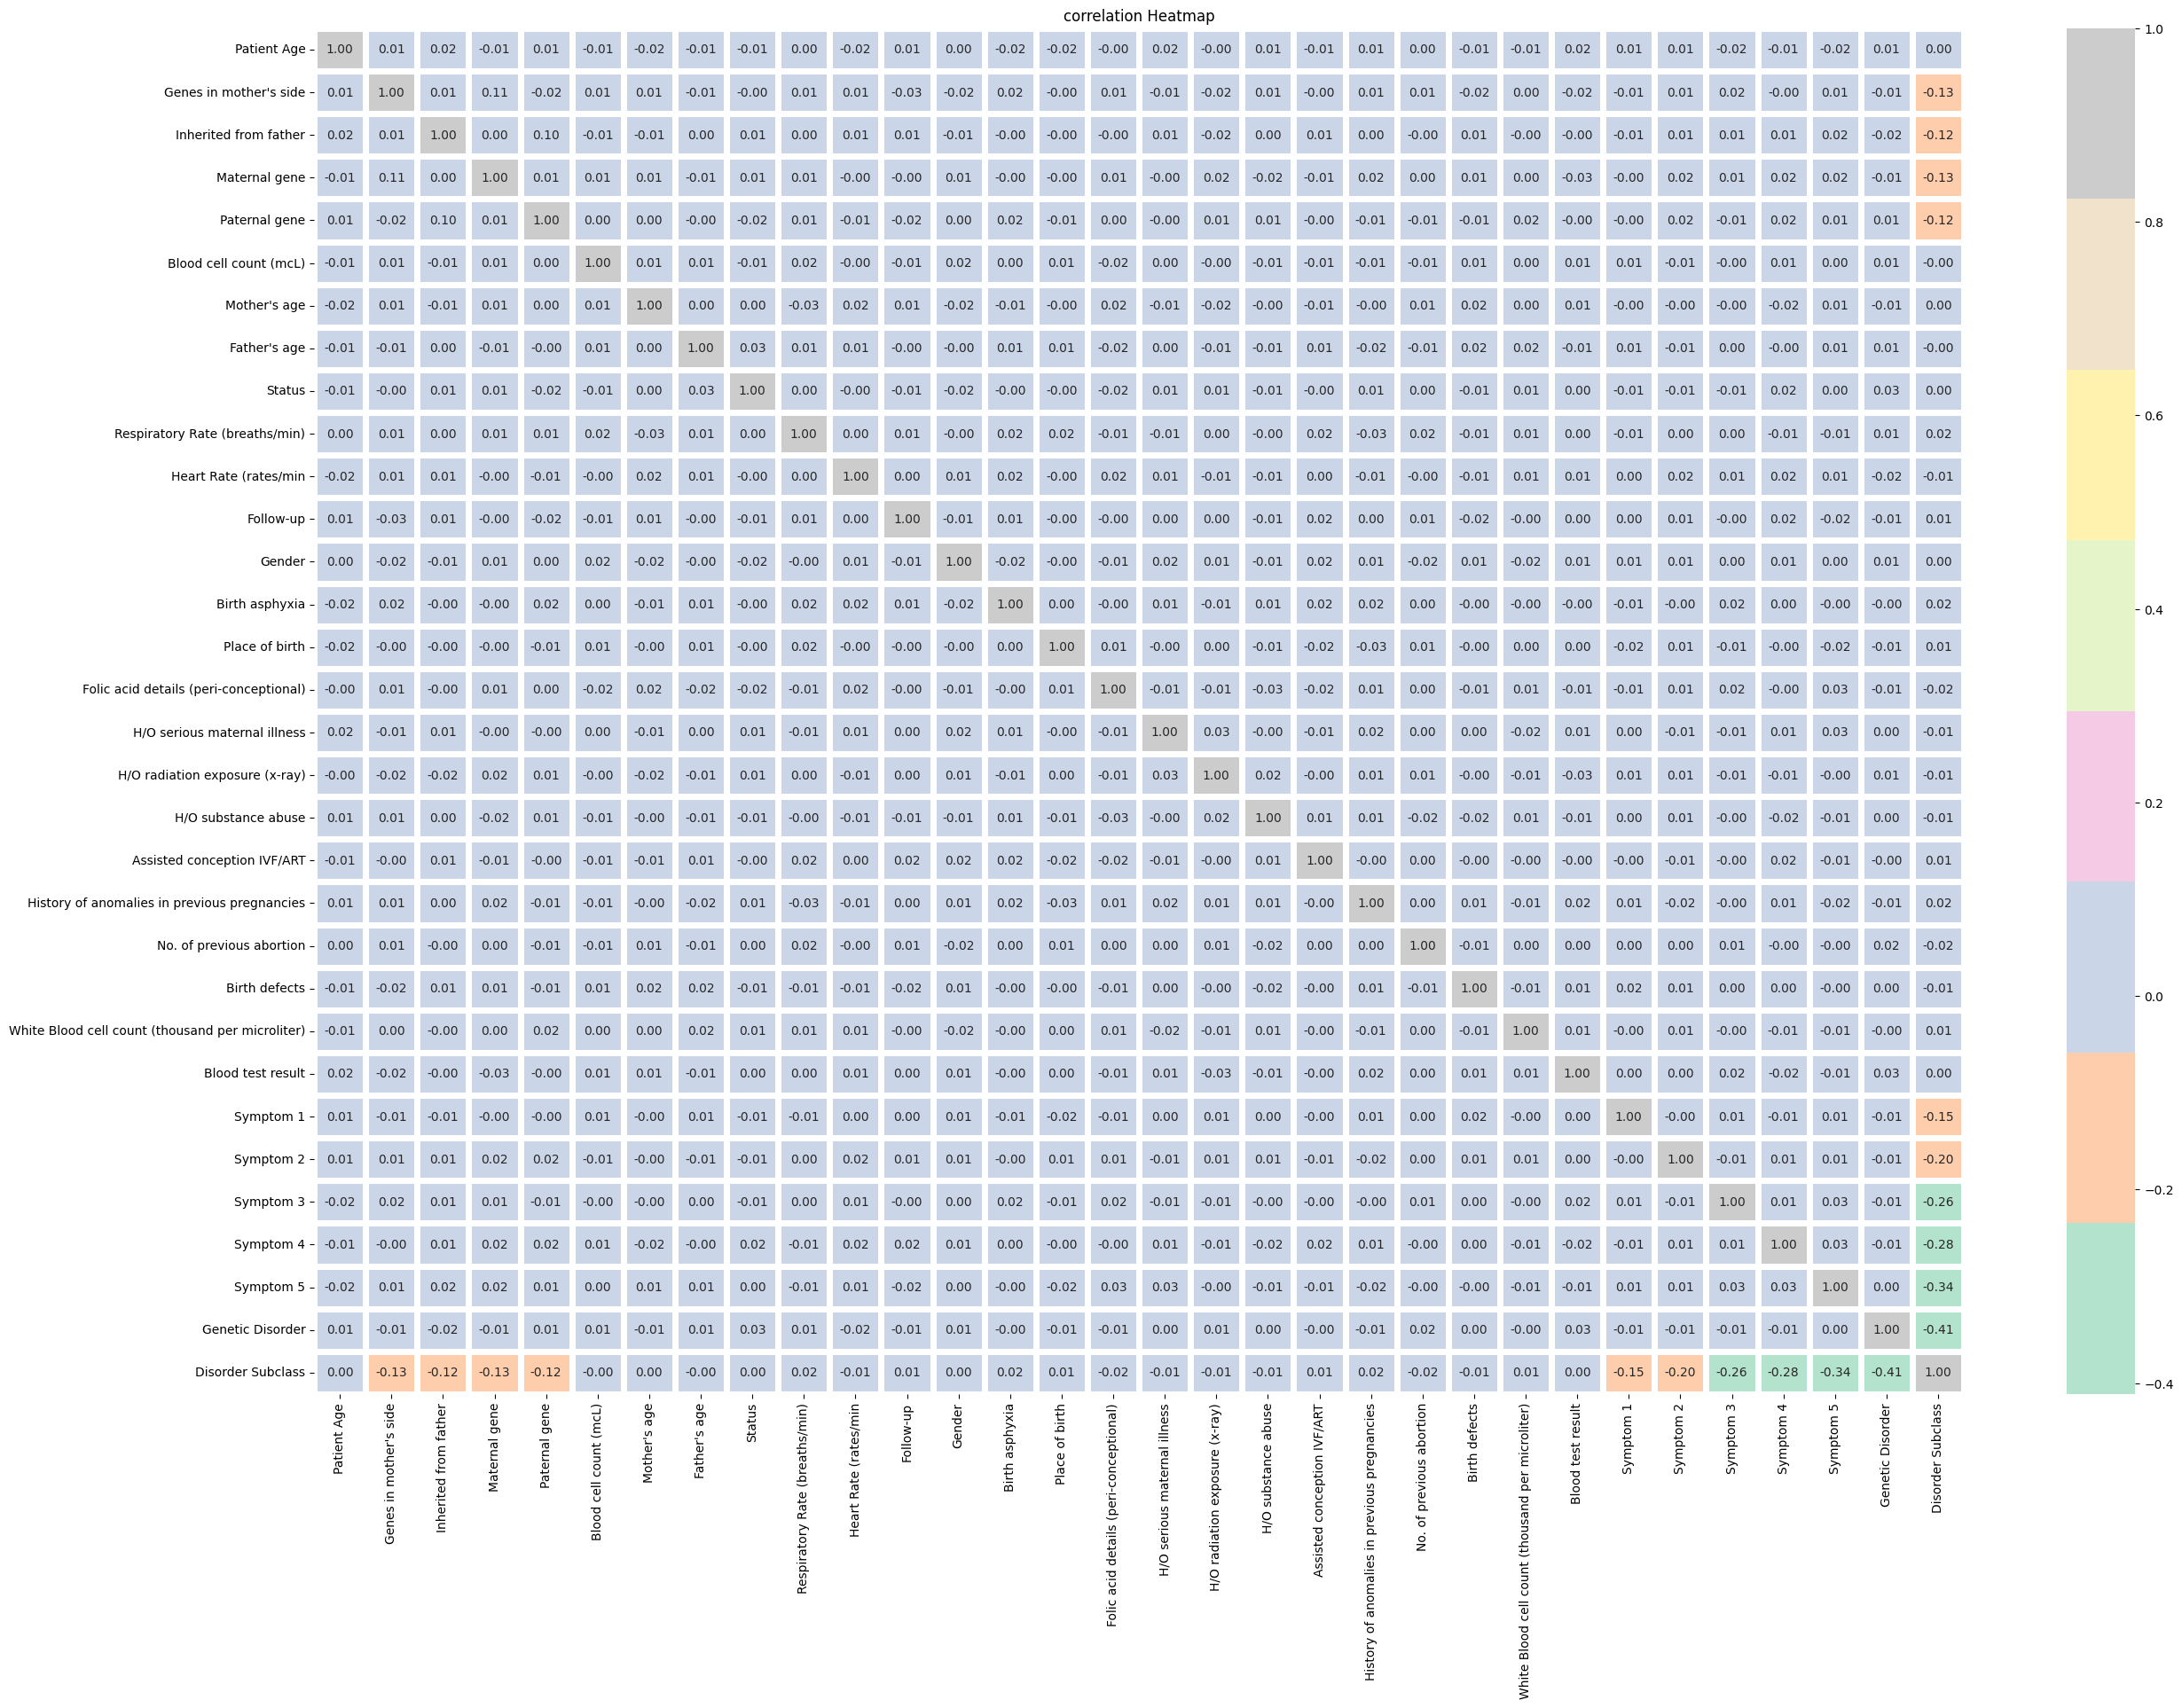

In [25]:
plt.figure(figsize=(30,20))
sns.heatmap(x.corr(),annot=True,fmt='.2f',cmap = 'Pastel2',linewidths = 5)
plt.title('correlation Heatmap')
plt.show()

In [26]:
train = x

<Axes: xlabel='Patient Age', ylabel="Father's age">

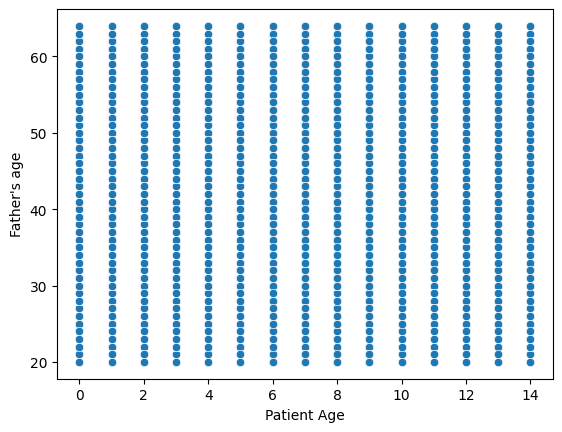

In [28]:
sns.scatterplot(train,x = train["Patient Age"],y = train["Father's age"])

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [102]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6776 entries, 8 to 22082
Data columns (total 30 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Age                                       6776 non-null   float64
 1   Genes in mother's side                            6776 non-null   object 
 2   Inherited from father                             6776 non-null   object 
 3   Maternal gene                                     6776 non-null   object 
 4   Paternal gene                                     6776 non-null   object 
 5   Blood cell count (mcL)                            6776 non-null   float64
 6   Mother's age                                      6776 non-null   float64
 7   Father's age                                      6776 non-null   float64
 8   Status                                            6776 non-null   object 
 9   Respiratory Rate (breat

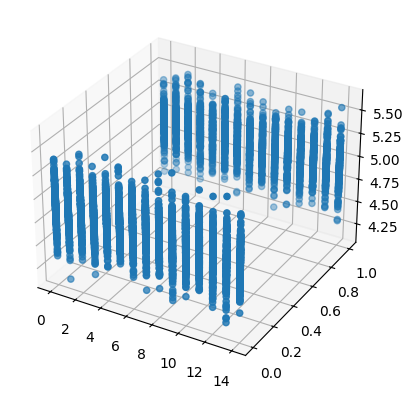

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.scatter(train["Patient Age"], train["Paternal gene"],train["Blood cell count (mcL)"])